In [1]:
# typical python libraries
import numpy as np
import matplotlib.pyplot as plt

# pytorch libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# huggingface libraries
from transformers import BertModel, BertTokenizer
from datasets import load_dataset, DatasetDict

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

# Import and process the dataset

In [3]:
# load the IMDB dataset (from HF)
dataset = load_dataset('imdb')

# reduce the size (overwriting the variable!)
dataset = DatasetDict({split:dataset[split].select(range(5_000,20_000)) for split in ['train','test']})

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

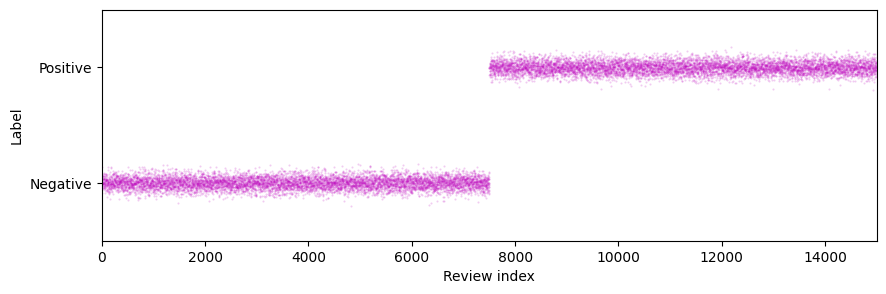

In [4]:
plt.figure(figsize=(10,3))
plt.plot(dataset['train']['label'] + np.random.randn(len(dataset['train']))/20,'m.',markersize=1,alpha=.2)

plt.gca().set(xlabel='Review index',ylabel='Label',yticks=[0,1],yticklabels=['Negative','Positive'],
              xlim=[0,len(dataset['train'])],ylim=[-.5,1.5])
plt.show()

In [5]:
# define a tokenization function that processes each data sample
def tokenize_function(one_sample):
  return tokenizer(
    one_sample['text'],
    max_length = 512,         # Maximum sequence length
    padding    = 'max_length',# Pad sequences to the maximum length
    truncation = True)        # Truncate sequences longer than max_length


# apply the tokenization function to the dataset (batched for efficiency)
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# remove text pair
tokenized_dataset = tokenized_dataset.remove_columns(['text'])

# change format to pytorch tensors
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# create DataLoaders for training and testing
train_dataloader = DataLoader(tokenized_dataset['train'], shuffle=True, batch_size=32)
test_dataloader  = DataLoader(tokenized_dataset['test'], batch_size=32)

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

# Create and precision-freeze the model

In [6]:
class BertForBinaryClassification(nn.Module):
  def __init__(self, num_labels=2):
    super(BertForBinaryClassification, self).__init__()

    # Load the pre-trained BERT model.
    self.bert = BertModel.from_pretrained('bert-base-uncased')

    # classification head that converts the 768-d pooled output into 2 final outputs.
    self.classifier = nn.Linear(768,2)
    self.dropout = nn.Dropout(self.bert.embeddings.dropout.p) # 10%

    # initialize the weights and biases
    nn.init.xavier_uniform_(self.classifier.weight)
    nn.init.zeros_(self.classifier.bias)


  def forward(self, input_ids, attention_mask=None, token_type_ids=None):

    # forward pass through the downloaded (pretrained) BERT
    outputs = self.bert(
      input_ids      = input_ids,
      attention_mask = attention_mask,
      token_type_ids = token_type_ids)

    # extract the pooled output and apply dropout
    pooled_output = self.dropout( outputs.pooler_output )

    # final push through the classification layer.
    logits = self.classifier(pooled_output)
    return logits

In [7]:
# create an instance of the model and test it:
model = BertForBinaryClassification().to(device)

# Freeze the attention weights

In [8]:
# Count the total number of parameters in the model
print(f'Total trainable paremeters in bert: {sum([torch.numel(params) for params in model.parameters() if params.requires_grad]):,}')

Total trainable paremeters in bert: 109,483,778


In [9]:
for name, p in model.named_parameters():
  if any(substring in name for substring in ['embeddings', 'attention']):
    p.requires_grad = False

In [10]:
# Count the total number of parameters in the model once again - after freeze
print(f'Total trainable paremeters in bert: {sum([torch.numel(params) for params in model.parameters() if params.requires_grad]):,}')

Total trainable paremeters in bert: 57,279,746


# Defince the scheduler and optimizer

In [11]:
from transformers import get_linear_schedule_with_warmup

num_samples = 300

optimizer = torch.optim.AdamW(nn.Linear(10,10).parameters(), lr=1e-5, weight_decay=0.01)


loss_fn = nn.CrossEntropyLoss()


scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(num_samples*.05),
    num_training_steps=num_samples * 1.5
)

In [12]:
# test to check the learning rates
lrs = np.zeros(num_samples)
for i in range(num_samples):

  optimizer.step() # update the optimizer
  scheduler.step() # update the scheduler

  lrs[i] = scheduler.get_last_lr()[0] # get the actual learning rate

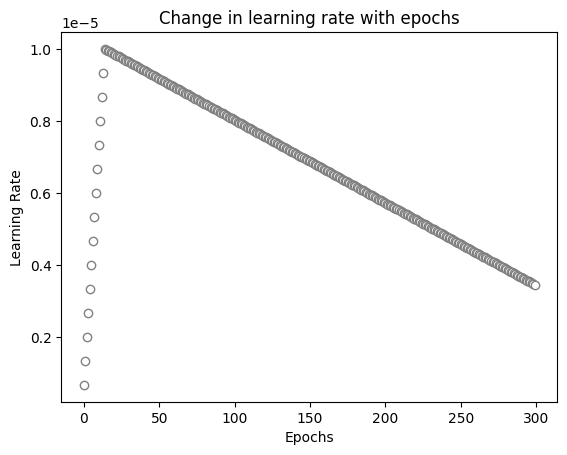

In [13]:
plt.plot(lrs,'o',markerfacecolor='w',c=[0.5,0.5,0.5])
plt.gca().set(xlabel='Epochs',ylabel='Learning Rate', title='Change in learning rate with epochs')
plt.show()

# Fine tune the model with gradient clipping and learning rate adjustments

In [14]:
# Initialize the metrics
train_losses = np.zeros(num_samples)
test_losses = np.zeros(num_samples)
train_accuracy = np.zeros(num_samples)
test_accuracy = np.zeros(num_samples)
norms = np.zeros((num_samples,2))

# Loop of data samples
for sampli in range(num_samples):

  model.train()

  # Get one batch of data
  batch = next(iter(train_dataloader))
  tokenz = batch['input_ids'].to(device)
  labels = batch['label'].to(device)
  attn   = batch['attention_mask'].to(device)

  # Clear the previous gradients
  optimizer.zero_grad()

  # Forward pass
  logits = model(input_ids=tokenz, attention_mask=attn)
  pred_labels = torch.argmax(logits, dim=1)

  # Calculate the loss
  loss = loss_fn(logits, labels)

  # Store the loss
  train_losses[sampli] = loss.item()
  train_accuracy[sampli] = torch.mean((pred_labels == labels).float()).item()

  # Backward pass
  loss.backward()

  # Get two graident norms
  norms[sampli,0] = torch.norm(model.bert.encoder.layer[7].output.dense.weight.grad).item()
  norms[sampli,1] = torch.norm(model.classifier.weight.grad).item()

  # Gradient clipping for regularization
  nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

  # Update the weights
  optimizer.step()
  scheduler.step()

  # Test the model and report losses for evey 10th sample
  if sampli % 10 == 0:

    # Set the model to evaluation mode
    model.eval()
    with torch.no_grad():
      for batch in test_dataloader:
        tokenz = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        attn_mask   = batch['attention_mask'].to(device)

        logits = model(input_ids=tokenz, attention_mask=attn_mask)
        pred_labels = torch.argmax(logits, dim=1)
        loss = loss_fn(logits, labels)
        test_losses[sampli] = loss.item()
        test_accuracy[sampli] = torch.mean((pred_labels == labels).float()).item()

    print(f'Sample {sampli:4}/{num_samples}, losses (train/ test): {train_losses[sampli]:.3f}/{test_losses[sampli]:.3f}, accuracies (train/ test): {train_accuracy[sampli]:.3f}/{test_accuracy[sampli]:.3f}')

Sample    0/300, losses (train/ test): 0.889/1.198, accuracies (train/ test): 0.406/0.042
Sample   10/300, losses (train/ test): 0.878/1.198, accuracies (train/ test): 0.562/0.042
Sample   20/300, losses (train/ test): 1.127/1.198, accuracies (train/ test): 0.219/0.042
Sample   30/300, losses (train/ test): 0.879/1.198, accuracies (train/ test): 0.406/0.042
Sample   40/300, losses (train/ test): 0.596/1.198, accuracies (train/ test): 0.750/0.042
Sample   50/300, losses (train/ test): 0.784/1.198, accuracies (train/ test): 0.500/0.042
Sample   60/300, losses (train/ test): 0.770/1.198, accuracies (train/ test): 0.531/0.042
Sample   70/300, losses (train/ test): 0.935/1.198, accuracies (train/ test): 0.375/0.042
Sample   80/300, losses (train/ test): 0.780/1.198, accuracies (train/ test): 0.469/0.042
Sample   90/300, losses (train/ test): 0.675/1.198, accuracies (train/ test): 0.625/0.042
Sample  100/300, losses (train/ test): 0.699/1.198, accuracies (train/ test): 0.625/0.042
Sample  11

KeyboardInterrupt: 

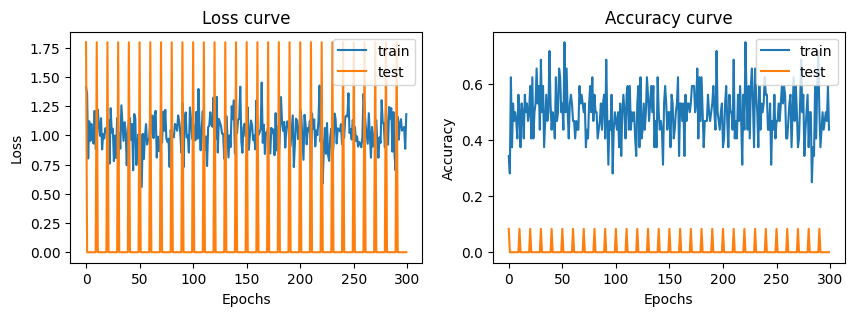

In [ ]:
# Plot the loss and accuracy curve
_,ax = plt.subplots(1,2,figsize=(10,3))

ax[0].plot(train_losses, label='train')
ax[0].plot(test_losses, label='test')
ax[0].set(xlabel='Epochs', ylabel='Loss', title='Loss curve')
ax[0].legend()

ax[1].plot(train_accuracy, label='train')
ax[1].plot(test_accuracy, label='test')
ax[1].set(xlabel='Epochs', ylabel='Accuracy', title='Accuracy curve')

ax[1].legend()
plt.show()